In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
# Explore the dataset structure
dataset_path = "/kaggle/input/bowl-2018-try-2"

# List all files and folders
for root, dirs, files in os.walk(dataset_path):
    print("Root:", root)
    print("Directories:", dirs)
    print("Files:", files[:5])  # Display first 5 files for brevity
    print("-" * 50)

Root: /kaggle/input/bowl-2018-try-2
Directories: ['validation folder', 'train folder', 'test folder']
Files: []
--------------------------------------------------
Root: /kaggle/input/bowl-2018-try-2/validation folder
Directories: ['labelcol', 'img']
Files: []
--------------------------------------------------
Root: /kaggle/input/bowl-2018-try-2/validation folder/labelcol
Directories: []
Files: ['0050.png', '0006.png', '0003.png', '0013.png', '0052.png']
--------------------------------------------------
Root: /kaggle/input/bowl-2018-try-2/validation folder/img
Directories: []
Files: ['0050.png', '0006.png', '0003.png', '0013.png', '0052.png']
--------------------------------------------------
Root: /kaggle/input/bowl-2018-try-2/train folder
Directories: ['labelcol', 'img']
Files: []
--------------------------------------------------
Root: /kaggle/input/bowl-2018-try-2/train folder/labelcol
Directories: []
Files: ['0115.png', '0050.png', '0501.png', '0263.png', '0133.png']
-------------

In [3]:
from skimage.io import imread
from skimage.transform import resize

# Define paths
train_img_path = "/kaggle/input/bowl-2018-try-2/train folder/img"
train_mask_path = "/kaggle/input/bowl-2018-try-2/train folder/labelcol"

# Define image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128  # Resized dimensions
IMG_CHANNELS = 3  # RGB

# Load and preprocess training images
def load_data(img_path, mask_path, img_height, img_width):
    images = []
    masks = []
    for file_name in os.listdir(img_path):
        # Load and normalize image
        img = imread(os.path.join(img_path, file_name))
        img = resize(img, (img_height, img_width, IMG_CHANNELS), mode='constant', preserve_range=True)
        img = img / 255.0  # Normalize to [0, 1]
        images.append(img)

        # Load and normalize corresponding mask
        mask = imread(os.path.join(mask_path, file_name), as_gray=True)
        mask = resize(mask, (img_height, img_width, 1), mode='constant', preserve_range=True)
        mask = mask / 255.0  # Normalize to [0, 1]
        masks.append(mask)

    return np.array(images), np.array(masks)

# Load training data
train_images, train_masks = load_data(train_img_path, train_mask_path, IMG_HEIGHT, IMG_WIDTH)

# Print shapes for confirmation
print("Train Images Shape:", train_images.shape)
print("Train Masks Shape:", train_masks.shape)

Train Images Shape: (520, 128, 128, 3)
Train Masks Shape: (520, 128, 128, 1)


In [4]:
def unet_model(input_size=(128, 128, 3)):
    inputs = Input(input_size)
    
    # Encoder (downsampling)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    
    # Bottleneck
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    
    # Decoder (upsampling)
    u1 = UpSampling2D((2, 2))(c4)
    u1 = concatenate([u1, c3])
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(u1)
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(c5)
    
    u2 = UpSampling2D((2, 2))(c5)
    u2 = concatenate([u2, c2])
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(u2)
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(c6)
    
    u3 = UpSampling2D((2, 2))(c6)
    u3 = concatenate([u3, c1])
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(u3)
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(c7)
    
    # Output layer
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c7)
    
    model = Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build the model
model = unet_model()
model.summary()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 768)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │  1,769,728 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ conv2d_9[0][0]  

 Total params: 7,782,913 (29.69 MB)

 Trainable params: 7,782,913 (29.69 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Split a small part of training data for validation
from sklearn.model_selection import train_test_split

# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(train_images, train_masks, test_size=0.2, random_state=42)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=30,
    verbose=1
)
# Generate raw predictions and check their range
raw_preds = model.predict(X_val)
print("Raw prediction range:", raw_preds.min(), raw_preds.max())

Epoch 1/30


I0000 00:00:1733764205.613383      93 service.cc:145] XLA service 0x7f6910002150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1733764205.613442      93 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1733764205.613446      93 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 1/26 ━━━━━━━━━━━━━━━━━━━━ 12:49 31s/step - accuracy: 0.0213 - loss: 0.6958

I0000 00:00:1733764232.745129      93 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


26/26 ━━━━━━━━━━━━━━━━━━━━ 41s 405ms/step - accuracy: 0.6788 - loss: 0.6480 - val_accuracy: 0.7873 - val_loss: 0.4750
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.7948 - loss: 0.4506 - val_accuracy: 0.7873 - val_loss: 0.3956
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.8043 - loss: 0.3700 - val_accuracy: 0.7873 - val_loss: 0.3155
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.8042 - loss: 0.2830 - val_accuracy: 0.7873 - val_loss: 0.2448
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.7987 - loss: 0.2328 - val_accuracy: 0.7871 - val_loss: 0.2055
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.8285 - loss: 0.1792 - val_accuracy: 0.8131 - val_loss: 0.1723
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.8298 - loss: 0.1686 - val_accuracy: 0.8155 - val_loss: 0.1586
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.8206 - loss: 0.1515 - val_accuracy: 0.8198 - val

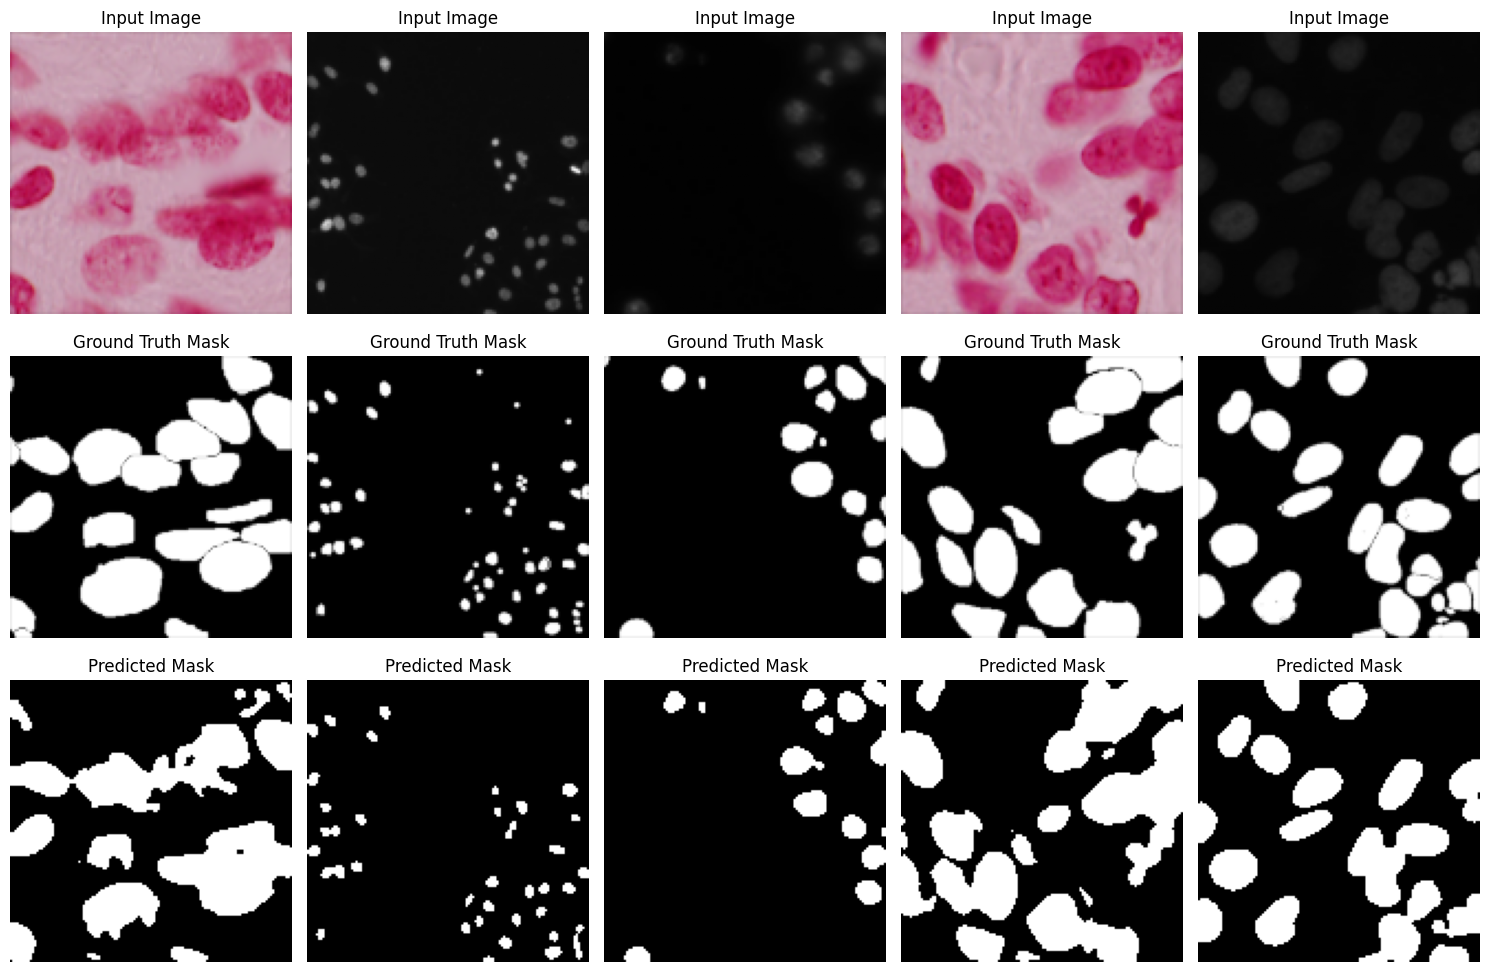

In [6]:
# Visualize a few samples
import random

# Threshold predictions at 0.5 to create binary masks
preds_binary = (raw_preds > 0.5).astype(np.uint8)

# Randomly select 5 samples
random_idx = random.sample(range(len(X_val)), 5)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_idx):
    # Input Image
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_val[idx])
    plt.title("Input Image")
    plt.axis('off')
    
    # Ground Truth Mask
    plt.subplot(3, 5, i + 6)
    plt.imshow(y_val[idx].squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')
    
    # Predicted Mask
    plt.subplot(3, 5, i + 11)
    plt.imshow(preds_binary[idx].squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
from sklearn.metrics import jaccard_score

def dice_coefficient(y_true, y_pred):
    """Calculate the Dice Coefficient."""
    smooth = 1.0  # Avoid division by zero
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def evaluate_performance(y_true, y_pred):
    """Evaluate Dice and IoU metrics."""
    dice = dice_coefficient(y_true, y_pred)
    iou = jaccard_score(y_true.flatten(), y_pred.flatten(), average='binary')
    accuracy = np.mean(y_true == y_pred)
    return dice, iou, accuracy

# Ensure y_val is binary
y_val_binary = (y_val > 0.5).astype(np.uint8)  # Threshold ground truth masks to binary

# Evaluate on validation set
dice, iou, accuracy = evaluate_performance(y_val_binary, preds_binary)

print(f"Dice Coefficient: {dice:.4f}")
print(f"IoU (Jaccard Index): {iou:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Dice Coefficient: 0.8975
IoU (Jaccard Index): 0.8141
Accuracy: 0.9714


In [9]:
model.save("unet_model.h5")